# Преобразование данных в тензоры + аугментация

In [ ]:
# Make transforms and use data loaders # We'll use these a lot, so make them variables
mean_nums = [0.485, 0.456, 0.406]
std_nums = [0.229, 0.224, 0.225]
chosen_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(size=384, scale=(0.4, 1.0)), # Больше зума на детали
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.05), # Иногда здания сняты под странным углом
        transforms.RandAugment(num_ops=2, magnitude=12), # Сильная аугментация
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)), # Боремся с "зубрежкой" конкретных фото
        transforms.Normalize(mean_nums, std_nums)
    ]),
    'val': transforms.Compose([
        transforms.Resize(410),
        transforms.CenterCrop(384),
        transforms.ToTensor(),
        transforms.Normalize(mean_nums, std_nums)
    ]),
    'test': transforms.Compose([
        transforms.Resize(410),
        transforms.CenterCrop(384),
        transforms.ToTensor(),
        transforms.Normalize(mean_nums, std_nums)
    ])
}


In [ ]:
data_dir = flat_root

chosen_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), chosen_transforms[x]) for x in ['train', 'val', 'test']}

In [ ]:
dataloaders = {x: torch.utils.data.DataLoader(chosen_datasets[x], batch_size=4, shuffle=(x == 'train'), num_workers=4) for x in ['train', 'val', 'test']}

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
dataset_sizes = {x: len(chosen_datasets[x]) for x in ['train', 'val', 'test']}
class_names = chosen_datasets['train'].classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(dataset_sizes, class_names, device)

{'train': 9831, 'val': 1228, 'test': 1232} ['21st_Century', 'Baroque', 'Classical', 'Early_Christian_Medieval', 'Eclecticism', 'Modernism', 'Neoclassicism', 'Renaissance_and_Colonialism', 'Revivalism'] cuda


## больше нейронов

In [ ]:
def create_model_parameters():

  res_mod_silu = models.resnet50(weights='IMAGENET1K_V2')

  for param in res_mod_silu.parameters():
        param.requires_grad = False

  in_feat = res_mod_silu.fc.in_features

  criterion = nn.CrossEntropyLoss()

  res_mod_silu.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.SiLU(),
    nn.Linear(1024, 512),
    nn.LayerNorm(512),
    nn.SiLU(),
    nn.Linear(512, 9)
)

  res_mod_silu = res_mod_silu.to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, res_mod_silu.parameters()), lr=0.0001, weight_decay=0.0001)
  exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer_silu, T_max=30, eta_min=1e-6)

  return res_mod_silu, criterion, optimizer_silu, exp_lr_scheduler

In [ ]:
model_2048, criterion, optimizer, scheduler = create_model_parameters()

In [ ]:
final_model, metrics = train_model(model_2048, criterion, optimizer, scheduler, dataloaders, dataset_sizes, '/content/drive/MyDrive/практика_модель', '2048_3')

Epoch 1/20
----------
Iterating through data...
train Loss: 1.4040 | Acc: 0.4944 | Weighted Acc: 0.4252 | F1-macro: 0.4840 | Top-1 Acc: 0.4944 | Top-3 Acc: 0.8011
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val Loss: 0.9916 | Acc: 0.6458 | Weighted Acc: 0.6094 | F1-macro: 0.6472 | Top-1 Acc: 0.6458 | Top-3 Acc: 0.9088
Epoch Time: 183.9013s

Epoch 2/20
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train Loss: 1.2098 | Acc: 0.5663 | Weighted Acc: 0.5087 | F1-macro: 0.5612 | Top-1 Acc: 0.5663 | Top-3 Acc: 0.8551
Iterating through data...


...

val Loss: 0.7674 | Acc: 0.7321 | Weighted Acc: 0.7003 | F1-macro: 0.7350 | Top-1 Acc: 0.7321 | Top-3 Acc: 0.9430
Epoch Time: 187.7188s

Epoch 20/20
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train Loss: 0.7979 | Acc: 0.7217 | Weighted Acc: 0.6854 | F1-macro: 0.7207 | Top-1 Acc: 0.7217 | Top-3 Acc: 0.9352
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val Loss: 0.7714 | Acc: 0.7182 | Weighted Acc: 0.6913 | F1-macro: 0.7216 | Top-1 Acc: 0.7182 | Top-3 Acc: 0.9373
Epoch Time: 186.3566s

Training complete in 62m 39s
Best val Weighted Acc: 0.700333 | Best F1-score: 0.7350 | Best Top-1 Acc: 0.7321 | Best Top-3 Acc: 0.9430


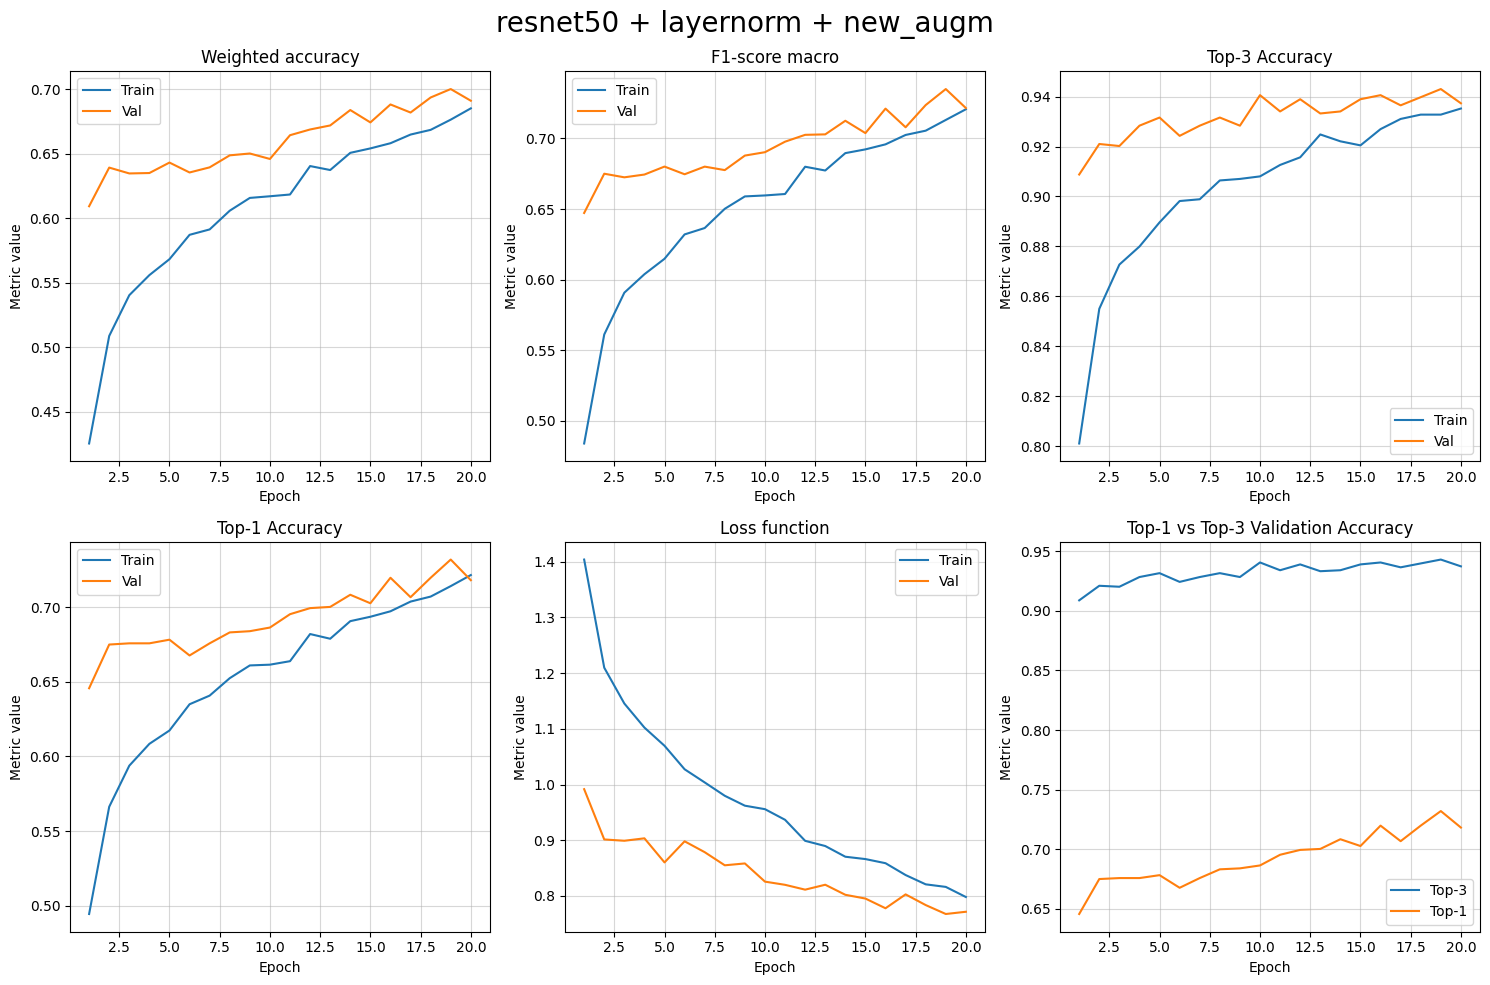

In [ ]:
visualize_metrics(metrics, 'resnet50 + layernorm + new_augm', 20)